In [4]:
import pandas as pd
from src.setup import get_base
from src.feature_engineering import engineer_features, tune_pca_and_kmeans
from src.analysis import run_pca, run_kmeans, plot_pca_clusters, find_optimal_k, pca
from sklearn.preprocessing import StandardScaler

In [5]:
df = get_base()

In [6]:
df_features = engineer_features(df)

In [7]:
from src.clustering import SegmentationPipeline


In [8]:
pipe = SegmentationPipeline(variance_threshold=0.95, max_clusters=10)

In [9]:
# Features vorbereiten
features_scaled, df_clean = pipe.prepare_features(df_features)

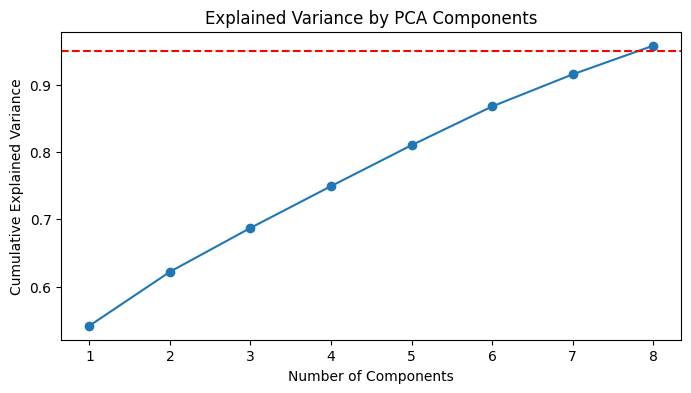

In [10]:
# PCA
components, pca, explained_var = pipe.run_pca(features_scaled)
pipe.plot_explained_variance()

In [11]:
# 1. Variante: Automatisch bestes k wählen
#model_auto, scores_auto = pipe.kmeans_clustering()
#pipe.plot_scores()
#pipe.plot_clusters()

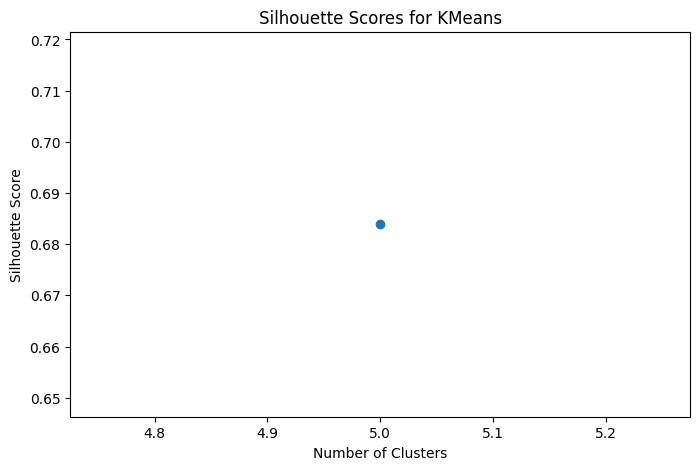

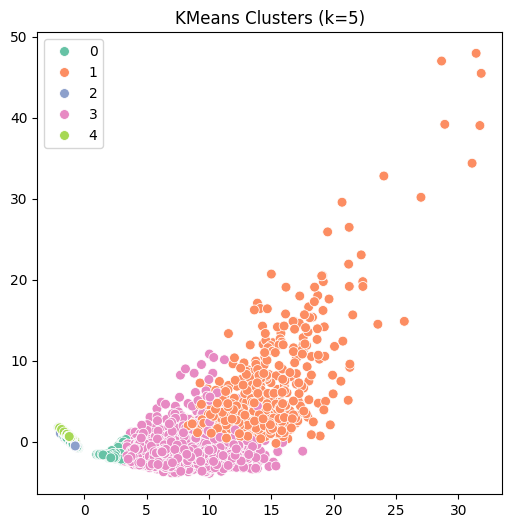

In [14]:
model_fixed, scores_fixed = pipe.kmeans_clustering(n_clusters=5)
pipe.plot_scores()
pipe.plot_clusters()

age                           avg_clicks                \
              mean median   min   max  count       mean median    min   
cluster                                                                 
0        37.731499   39.0   0.0  80.0  24283   0.137503   0.00  0.000   
1         0.000000    0.0   0.0   0.0    607  36.235966  36.50  8.625   
2        42.776058   44.0  18.0  86.0   5622   0.000000   0.00  0.000   
3         0.012770    0.0   0.0  65.0   5090  15.716711  15.25  4.125   
4        49.296066   49.0  20.0  90.0  19499   0.000000   0.00  0.000   

                         ... total_flight_fare_usd                          \
             max  count  ...                  mean   median  min       max   
cluster                  ...                                                 
0         26.375  24283  ...              0.743127     0.00  0.0    786.29   
1        109.125    607  ...           3509.427381  2003.54  0.0  29185.04   
2          0.000   5622  ...              0.000000     0.00  0.0      0.00   
3         47.125   5090  ...           1043.177821   864.14  0.0   7614.69   
4          0.000  19499  ...              0.000000     0.00  0.0      0.00   

               n_unique_destinations                          
         count                  mean median  min  max  count  
cluster                                                       
0        24283              0.002100    0.0  0.0  2.0  24283  
1          607              2.426689    2.0  0.0  8.0    607  
2         5622              0.000000    0.0  0.0  0.0   5622  
3         5090              2.235363    2.0  0.0  7.0   5090  
4        19499              0.000000    0.0  0.0  0.0  19499  

[5 rows x 80 columns]

,age,avg_clicks,total_cancellation,gender,married,session_duration_min,avg_flight_discount,total_flight_discount,avg_hotel_discount,total_hotel_discount,total_sessions,total_flights_booked,total_hotels_booked,avg_flight_fare_usd,total_flight_fare_usd,n_unique_destinations
cluster,,,,,,,,,,,,,,,,
0,37.731499,0.137503,0.000000,0.0,0.000000,3.103683,0.000702,0.005683,0.000369,0.003006,0.100647,0.002100,0.006713,0.740667,0.743127,0.002100
1,0.000000,36.235966,1.001647,0.0,0.000000,0.000000,0.281948,2.321252,0.241337,1.985173,8.245470,3.546952,3.421746,1197.846820,3509.427381,2.426689
2,42.776058,0.000000,0.000000,1.0,0.393454,3.573769,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.012770,15.716711,0.000000,0.0,0.000000,0.000213,0.175923,1.439489,0.132570,1.084086,8.183694,2.359332,2.469941,399.997940,1043.177821,2.235363
4,49.296066,0.000000,0.000000,0.0,0.999590,2.953827,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


/Users/kiko/Desktop/github/traveltide/src/clustering.py:140: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y=feature, data=df_with_clusters, palette="Set2")


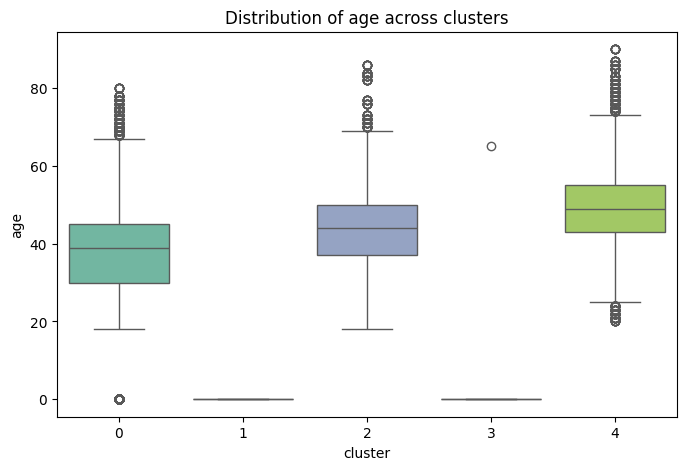

ValueError: total_hotel_spend_usd not in DataFrame

In [20]:
# Cluster zuordnen
df_clusters = pipe.assign_clusters(df_features)

# Überblick
summary = pipe.cluster_summary(df_clusters)
display(summary)

# Einfachere Übersicht: Cluster-Mittelwerte
means = pipe.cluster_means(df_clusters)
display(means)

# Beispiel: Altersverteilung in Clustern
pipe.plot_cluster_feature(df_clusters, "age")

# Beispiel: Hotel Spending in Clustern
pipe.plot_cluster_feature(df_clusters, "total_hotel_spend_usd")